# Import and Global Param


In [15]:
# Import modules
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
%matplotlib inline
import seaborn as sns
sns.set_style("ticks")
import jax
from jax import config
import numpy as np
os.environ["USE_MASSIVE_NEUTRINOS"] = "0" #Def we use normal DISCO-DJ or Massive neutrinos version
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
print(device)

from discodj import DiscoDJ
from discodj.cosmology.nu_background import get_masses
plt.rcParams['image.cmap'] = "rocket"
print(jax.__version__)

import baccoemu

import camb
from camb import model
from classy import Class
from scipy.optimize import fsolve
from scipy.interpolate import interp1d

jax.config.update("jax_enable_x64", True) 
import jax.numpy as jnp
from discoeb.background import evolve_background
from discoeb.perturbations import evolve_perturbations, get_power, evolve_perturbations_batched


#from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
#mpl.use("pgf")
#mpl.rcParams.update({
#    "pgf.texsystem": "pdflatex",
#    "font.family": "serif",
#    "text.usetex": True, 
#})

gpu
0.7.2


In [98]:
##### COSMOLOGY #####
cosmo = {
    "h": 0.67,
    "H0": 67,
    "ombh2": 0.049*0.67**2,
    "omch2": 0.269984542*0.67**2,
    "As": 2.215e-09,
    "ns": 0.9619,
    "sum_mnu": 0.06,      # total neutrino mass [eV]
    "tau": 0.0952,
    "w0": -1.0,
    "wa": 0.0,
    "z": 0.0,
    "Tcmb": 2.7255,
}

h = cosmo["h"]
n_s = cosmo["ns"]
A_s  = cosmo["As"]
z = cosmo["z"]
a = 1.0 / (1.0 + z)
sum_mnu = cosmo["sum_mnu"]

omega_nu = cosmo["sum_mnu"]/(93.14*(h**2))
omega_b = cosmo["ombh2"] / h**2
omega_cdm = cosmo["omch2"] / h**2 
omega_cdm_nu  = cosmo["omch2"] / h**2  - omega_nu
omega_cold = omega_b + omega_cdm
omega_cold_nu = omega_b + omega_cdm_nu

print("Omega_b=",omega_b)
print("Omega_nu=",omega_nu)
print("Omega_cdm=",omega_cdm)
print("Omega_nu+Omega_cdm_nu=",omega_nu+omega_cdm_nu)
print("Omega_m=",omega_cold+omega_nu)

###### Neutrinos masses ######
mnu_massless = [0,0,0]
mnu_deg = [cosmo["sum_mnu"]/3,cosmo["sum_mnu"]/3,cosmo["sum_mnu"]/3] # Array of neutrinos masses for degenerarte case 
m1,m2,m3 = get_masses(2.45e-3,7.50e-5,cosmo["sum_mnu"],'NH')
mnu_NH =[m1,m2,m3]
m1,m2,m3 = get_masses(2.45e-3,7.50e-5,cosmo["sum_mnu"],'IH')
mnu_IH = [m1,m2,m3]

print("Degenerate",mnu_deg)
print("NH",mnu_NH)
print("IH",mnu_IH)

# modes to sample
nmodes = 512
kmin = 1e-3
kmax = 10
aexp = 1.0
zout = 0.0

#Linear Suppression 
f_nu = omega_nu / (omega_cold+omega_nu)
supp_P = 1-8*f_nu
supp_Pcb = 1-6*f_nu

#k scale
k_h = np.logspace(-4, np.log10(4.9), 600)  # h/Mpc; BACCO nonlinear is used only over this range.
k_check = np.array([1e-3, 1e-2, 1e-1, 1.0])

Omega_b= 0.049
Omega_nu= 0.0014350446416078848
Omega_cdm= 0.269984542
Omega_nu+Omega_cdm_nu= 0.269984542
Omega_m= 0.32041958664160786
Degenerate [0.02, 0.02, 0.02]
NH [np.float64(0.0013432618738275445), np.float64(0.008763809243797965), np.float64(0.04989292888237449)]
IH [np.float64(0.03952939325011442), np.float64(0.040466936265576015), np.float64(nan)]


/home/raphael/cosmo-sims/DISCO-DJ/src/discodj/cosmology/nu_background.py:145: RuntimeWarning: invalid value encountered in scalar power
  m3 = (delta_m_squared_atm + 0.5*(m2**2. + m1**2.))**0.5


# Reference Codes


## BACCO

In [99]:
bacco_kwargs = dict(
    omega_cold=omega_cold,
    omega_baryon=omega_b,
    A_s=cosmo["As"],
    hubble=h,
    ns=cosmo["ns"],
    neutrino_mass=0,
    w0=cosmo["w0"],
    wa=cosmo["wa"],
    expfactor=a,
    k=k_h,
    cold=True,
)

mp_bacco = baccoemu.Matter_powerspectrum(
    linear=True,
    nonlinear_boost=True,
    baryonic_boost=False,
    verbose=False,
)

# Computation of Linear spectra for massless 
k_bacco_lin_h, P_bacco_lin = mp_bacco.get_linear_pk(**bacco_kwargs)
# Computation of Non-Linear spectra for massless 
k_bacco_nl_h, P_bacco_nl = mp_bacco.get_nonlinear_pk(**bacco_kwargs, baryonic_boost=False)
pk_ref = np.exp(interp1d(np.log(k_bacco_lin_h), np.log(P_bacco_lin), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
pk_nl_ref = np.exp(interp1d(np.log(k_bacco_nl_h), np.log(P_bacco_nl), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
sigma8 = mp_bacco.get_sigma8(**bacco_kwargs)

# Save the Massless Linear
np.savetxt("Pk_cb_massless_z0_BACCO.txt",np.column_stack([k_h, pk_ref]),header="k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, massless neutrinos)")

################################################################################################

#Neutrino masses 

#Modify the param for the massive neutrinos

#bacco_kwargs['omega_cold'] = omega_cold_nu
bacco_kwargs['neutrino_mass'] = cosmo["sum_mnu"] 
# Computation of Linear spectra for massive 
k_bacco_lin_h, P_bacco_lin = mp_bacco.get_linear_pk(**bacco_kwargs)
# Computation of Non-Linear spectra for massive
k_bacco_nl_h, P_bacco_nl = mp_bacco.get_nonlinear_pk(**bacco_kwargs, baryonic_boost=False)
pk_lin = np.exp(interp1d(np.log(k_bacco_lin_h), np.log(P_bacco_lin), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
pk_nl = np.exp(interp1d(np.log(k_bacco_nl_h), np.log(P_bacco_nl), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))

# Save the Massive Linear
fname = f"Pk_cb_sumMnu_{cosmo["sum_mnu"]:.2f}eV_z0_BACCO.txt"
np.savetxt(fname,np.column_stack([k_h, pk_lin]),header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, sum m_nu = {cosmo["sum_mnu"]} eV)")

    


## CLASS

In [100]:
#Param
class_params = {
    "output": "mPk",
    "h": h,
    "omega_b": cosmo["ombh2"],
    "omega_cdm": cosmo["omch2"],
    "A_s": cosmo["As"],
    "n_s": cosmo["ns"],
    "tau_reio": cosmo["tau"],
    "N_ncdm": 1,
    'deg_ncdm': 3,
    "m_ncdm": 1e-10/3,
    "N_ur": 0,
    "P_k_max_h/Mpc": 10.0,
    "z_pk": z,
    'T_cmb': 2.7255,
    'YHe': 0.24,
    'T_ncdm': 0.71611,
    
}

class_cosmo = Class()
class_cosmo.set(class_params)
class_cosmo.compute()

Pkbc_CLASS = h**3 * np.array([class_cosmo.pk_cb_lin(float(h * kk), z) for kk in k_h])

#Save the Massless for input
np.savetxt(
    "Pk_cb_massless_z0_CLASS.txt",
    np.column_stack([k_h, Pkbc_CLASS]),
    header="k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, massless neutrinos)"
)


#########################################################


class_cosmo.struct_cleanup()
class_cosmo.empty()
class_params = {
    "output": "mPk",
    "h": h,
    "omega_b": cosmo["ombh2"],
    "omega_cdm":cosmo["omch2"],#omega_cdm_nu*h**2,
    "A_s": cosmo["As"],
    "n_s": cosmo["ns"],
    "tau_reio": cosmo["tau"],
    "N_ncdm": 1,
    "m_ncdm": cosmo["sum_mnu"]/3,
    'deg_ncdm': 3,
    "N_ur": 0,
    "P_k_max_h/Mpc": 10.0,
    "z_pk": z,
    'T_cmb': 2.7255,
    'YHe': 0.24,
    'T_ncdm': 0.71611,
    }
class_cosmo = Class()
class_cosmo.set(class_params)
class_cosmo.compute()
Pkbc_CLASS_nu = h**3 * np.array([class_cosmo.pk_cb_lin(float(h * kk), z) for kk in k_h])
#Save PS for input
fname = f"Pk_cb_sumMnu_{cosmo["sum_mnu"]:.2f}eV_z0_CLASS.txt"
np.savetxt(
    fname,
    np.column_stack([k_h, Pkbc_CLASS_nu]),
    header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, sum m_nu = {cosmo["sum_mnu"]} eV)"
)
class_cosmo.struct_cleanup()
class_cosmo.empty()


## CAMB

In [101]:
pars = camb.CAMBparams()
pars.set_cosmology(
    H0=cosmo["H0"],
    ombh2=cosmo["ombh2"],
    omch2=cosmo["omch2"],
    mnu=0,
    omk=0.0,
    tau=cosmo["tau"],
)
pars.InitPower.set_params(As=cosmo["As"], ns=cosmo["ns"])
pars.Reion.Reionization = True
pars.set_matter_power(redshifts=[z], kmax=10.0,accurate_massive_neutrino_transfers=True)
pars.NonLinear = model.NonLinear_none
pars.set_accuracy(AccuracyBoost=3.0 , DoLateRadTruncation=False, lAccuracyBoost=3.0)
camb_results = camb.get_results(pars)
k_camb_h, z_camb, P_camb_cb = camb_results.get_matter_power_spectrum(
    minkh=1e-4,
    maxkh=10.0,
    npoints=1200,
    var1=model.Transfer_nonu,
    var2=model.Transfer_nonu,
)
P_camb_cb = P_camb_cb[0]
P_camb_cb_grid = np.exp(
    interp1d(np.log(k_camb_h), np.log(P_camb_cb), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h))
)

###############################################################

pars = camb.CAMBparams()
pars.set_cosmology(
    H0=cosmo["H0"],
    ombh2=cosmo["ombh2"],
    omch2= cosmo["omch2"],# omega_cdm_nu*h**2,
    mnu=cosmo["sum_mnu"],
    num_massive_neutrinos=3,
    neutrino_hierarchy='degenerate',
    omk=0.0,
    tau=cosmo["tau"],
)
pars.InitPower.set_params(As=cosmo["As"], ns=cosmo["ns"])
pars.set_matter_power(redshifts=[z], kmax=10.0,accurate_massive_neutrino_transfers=True)
pars.Reion.Reionization = True
pars.NonLinear = model.NonLinear_none
camb_results = camb.get_results(pars)
k_camb_h, z_camb, P_camb_cb = camb_results.get_matter_power_spectrum(
    minkh=1e-4,
    maxkh=10.0,
    npoints=1200,
    var1=model.Transfer_nonu,
    var2=model.Transfer_nonu,
)
P_camb_cb = P_camb_cb[0]
P_camb_cb_grid_nu = np.exp(
    interp1d(np.log(k_camb_h), np.log(P_camb_cb), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h))
)

## DISCOEB

In [102]:
@jax.jit
def compute_matter_power(sum_mnu):

    #Set param
    param = {}
    param['Omegam']  = omega_cold                           # Total matter density parameter
    param['Omegab']  = omega_b      
    param['Omegak']  = 0                     # Baryon density parameter
    param['w_DE_0']  = cosmo["w0"]                         # Dark energy equation of state parameter today
    param['w_DE_a']  = cosmo["wa"]                           # Dark energy equation of state parameter time derivative
    param['cs2_DE']  =  1.0                           # Dark energy sound speed squared
    param['A_s']     = cosmo["As"]                             # Scalar amplitude of the primordial power spectrum
    param['n_s']     = cosmo["ns"]                              # Scalar spectral index
    param['H0']      = cosmo["H0"]                           # Hubble constant today in units of 100 km/s/Mpc
    param['Tcmb']    = cosmo["Tcmb"]                              # CMB temperature today in K
    param['YHe']     = 0.248                              # Helium mass fraction
    param['Neff']    = 2.046                            # Effective number of ultrarelativistic neutrinos                                          
    param['Nmnu']    = 1                                # Number of massive neutrinos (must be 1 currently)
    param['mnu']     = sum_mnu                              # Sum of neutrino masses in eV 
    #param['k_p']     =  0.05                             # Pivot scale in 1/Mpc
    
    # modes to sample
    nmodes = 512                         # number of modes to sample                        

    #Evolve Background
    param = evolve_background(param=param, thermo_module='RECFAST')
    aexp_out = jnp.array([aexp])

    #Evolve Perturbation
    y, kmodes = evolve_perturbations_batched( param=param, kmin=kmin, kmax=kmax, num_k=nmodes, aexp_out=aexp_out,
                                    lmaxg = 31, lmaxgp = 31, lmaxr = 31, lmaxnu = 31, nqmax = 5,
                                    max_steps=32768,
                                    rtol=1e-5, atol=1e-5, batch_size=32 )
    #Compute CB spectrum
    Pkbc = get_power( k=kmodes, y=y[:,0,:], idx=6, param=param )
    return Pkbc, kmodes


##Compute linear Massless CB spectrum
#Pkm, kmodes = compute_matter_power(0)
#Pcb_EB = (h**3) * np.exp(interp1d(np.log(kmodes), np.log(Pkm), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
#
##Save for input 
#np.savetxt(
#    "Pk_cb_massless_z0_DISCOEB.txt",
#    np.column_stack([kmodes, Pcb_EB]),
#    header="k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, massless neutrinos)"
#)
#
#
#for sum_masses in masses:
#
#    #Compute Linear Massive CB spectrum
#    Pkm_nu, kmodes_nu = compute_matter_power(sum_masses)
#    Pcb_EB_nu = (h**3) * np.exp(interp1d(np.log(kmodes_nu), np.log(Pkm_nu), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
#
#    #Save for input
#    fname = f"Pk_cb_sumMnu_{sum_masses:.2f}eV_z0_DISCOEB.txt"
#    np.savetxt(
#        fname,
#        np.column_stack([kmodes, Pcb_EB_nu]),
#        header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, sum m_nu = {sum_masses} eV)"
#    )

## Linear Spectra

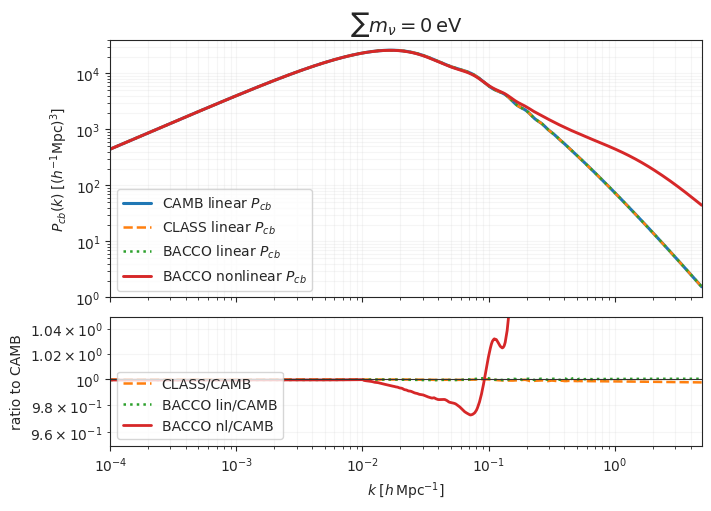

In [103]:
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7, 5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

ax.loglog(k_h, P_camb_cb_grid, color="C0", lw=2.2, label=r"CAMB linear $P_{cb}$")
ax.loglog(k_h, Pkbc_CLASS, color="C1", lw=1.8, ls="--", label=r"CLASS linear $P_{cb}$")
ax.loglog(k_h, pk_ref, color="C2", lw=1.8, ls=":", label=r"BACCO linear $P_{cb}$")
ax.loglog(k_h, pk_nl_ref, color="C3", lw=2.1, label=r"BACCO nonlinear $P_{cb}$")
#ax.loglog(k_h, Pcb_EB, color="C4", lw=2.1, label=r"DISCOEB linear $P_{cb}$")

ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend()
ax.grid(True, which="both", alpha=0.18)
ax.set_title(rf"$\sum m_\nu = 0\,\mathrm{{eV}}$",fontsize=14)

axr.semilogx(k_h, Pkbc_CLASS / P_camb_cb_grid, color="C1", lw=1.8, ls="--", label="CLASS/CAMB")
axr.semilogx(k_h, pk_ref / P_camb_cb_grid, color="C2", lw=1.8, ls=":", label="BACCO lin/CAMB")
axr.semilogx(k_h, pk_nl_ref / P_camb_cb_grid, color="C3", lw=2.0, label="BACCO nl/CAMB")
#axr.semilogx(k_h, Pcb_EB / P_camb_cb_grid, color="C4", lw=2.0, label="DISCOEB nl/CAMB")
axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio to CAMB")
axr.set_xlim(k_h.min(), k_h.max())
axr.set_yscale("log")
axr.set_ylim(0.95,1.05)
axr.legend(loc=3)
axr.grid(True, which="both", alpha=0.18)

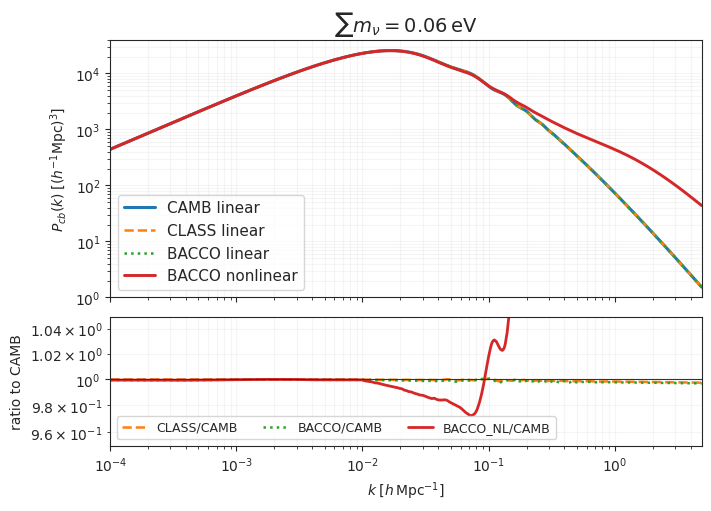

In [104]:
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7, 5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

ax.loglog(k_h, P_camb_cb_grid_nu, color="C0", lw=2.2, label=r"CAMB linear")
ax.loglog(k_h, Pkbc_CLASS_nu, color="C1", lw=1.8, ls="--", label=r"CLASS linear")
ax.loglog(k_h, pk_lin, color="C2", lw=1.8, ls=":", label=r"BACCO linear ")
ax.loglog(k_h, pk_nl, color="C3", lw=2.1, label=r"BACCO nonlinear")
#ax.loglog(k_h, Pcb_EB_nu, color="C4", lw=2.1, label=r"DISCOEB linear $P_{cb}$")

ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend(loc=3,prop={'size': 11})
ax.grid(True, which="both", alpha=0.18)
ax.set_title(rf"$\sum m_\nu = {cosmo["sum_mnu"]}\,\mathrm{{eV}}$",fontsize=14)

axr.semilogx(k_h, Pkbc_CLASS_nu / P_camb_cb_grid_nu, color="C1", lw=1.8, ls="--", label="CLASS/CAMB")
axr.semilogx(k_h, pk_lin / P_camb_cb_grid_nu, color="C2", lw=1.8, ls=":", label="BACCO/CAMB")
axr.semilogx(k_h, pk_nl / P_camb_cb_grid_nu, color="C3", lw=2.0, label="BACCO_NL/CAMB")
#axr.semilogx(k_h, Pcb_EB_nu / P_camb_cb_grid_nu, color="C4", lw=2.0, label="DISCOEB nl/CAMB")
axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio to CAMB")
axr.set_xlim(k_h.min(), k_h.max())
axr.set_yscale("log")
axr.set_ylim(0.95,1.05)
axr.legend(loc=3,prop={'size': 9},ncol=3)
axr.grid(True, which="both", alpha=0.18)
#plt.savefig('spectra_ref.pgf')

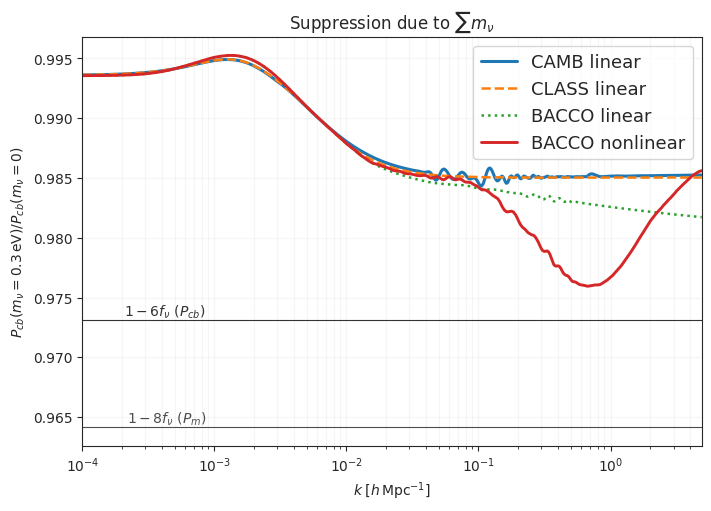

In [105]:
fig, ax = plt.subplots(
    figsize=(7, 5),
    constrained_layout=True,
)

# Ratios massive / massless
ratio_camb     = P_camb_cb_grid_nu / P_camb_cb_grid
ratio_class    = Pkbc_CLASS_nu    / Pkbc_CLASS
ratio_bacco    = pk_lin           / pk_ref
ratio_bacco_nl = pk_nl            / pk_nl_ref
# ratio_disco = Pcb_EB_nu / Pcb_EB

ax.semilogx(k_h,ratio_camb,color="C0",lw=2.2,label="CAMB linear",)
ax.semilogx(k_h,ratio_class,color="C1",lw=1.8,ls="--",label="CLASS linear",)
ax.semilogx(k_h,ratio_bacco,color="C2",lw=1.8,ls=":",label="BACCO linear",)
ax.semilogx(k_h,ratio_bacco_nl,color="C3",lw=2.1,label="BACCO nonlinear",)
# ax.semilogx(k_h, ratio_disco, color="C4", lw=2.1, label="DISCOEB")

ax.axhline(supp_Pcb, color="0.2", lw=0.8)
ax.axhline(supp_P,   color="0.3", lw=0.8)

ax.annotate(
    r"$1-6f_\nu$ ($P_{cb}$)",
    xy=(0.2, supp_Pcb),
    xycoords=("axes fraction", "data"),
    ha="right",
    va="bottom",
    color="0.2",
)

ax.annotate(
    r"$1-8f_\nu$ ($P_m$)",
    xy=(0.2, supp_P),
    xycoords=("axes fraction", "data"),
    ha="right",
    va="bottom",
    color="0.3",
)

ax.set_xscale("log")
ax.set_xlim(k_h.min(), k_h.max())

ax.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
ax.set_ylabel(
    r"$P_{cb}(m_\nu=0.3\,{\rm eV}) / P_{cb}(m_\nu=0)$"
)

ax.set_title(r"Suppression due to $\sum m_\nu $")

ax.legend(prop={'size': 13})
ax.grid(True, which="both", alpha=0.18)

plt.show()
#plt.savefig('supp_ref.pgf')



In [106]:
print(ratio_class[-1]-ratio_bacco[-1])

0.0033095723316519665


# N-body DISCODJ

## Linear Suppresion

In [107]:
# Set the parameters
name = "3D_analysis"
dim = 3
precision = "double"
if precision == "double":
    config.update("jax_enable_x64", True)

# Define the boxsize and resolution
boxsize = 4000  # in Mpc/h
res = 128  # the particles live on a Lagrangrian grid of resolution (res)^dim

results_disco = []

# The cosmology can be provided as a dictionary or a string for a pre-defined cosmology (e.g. "CamelsCV" for the Camels Cosmic Variance suite).
# cosmo = "CamelsCV"
cosmo = dict(Omega_c=omega_cdm,  # cold dark matter content
             Omega_b=omega_b,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
             h=h,  # dimensionless Hubble constant
             n_s=n_s,  # scalar spectral index
             sigma8=0.8159,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
             mnu = 0) #Neutrino mass (eV)

dj = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)
print(dj)
dj = dj.with_timetables()
dj = dj.with_linear_ps(fix_sigma8=True, transfer_function="from_file", filename="Pk_cb_massless_z0_BACCO.txt")
white_noise_field = dj.get_ngenic_noise(seed=13)  # a white noise field, defined in real space
dj = dj.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
k_pre, Pk_pre, _ = dj.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)

n_order = 2
stepper = "bullfrog"
method = "pm"
res_pm = dj.res
time_var = "D"
antialias = 0
grad_kernel_order = 4
laplace_kernel_order = 0
worder = 2
n_resample = 3
deconvolve = True
nlpt_order_ics = n_order
chunk_size = None  # if you are running out of GPU memory, doing the mass assignment in smaller chunks might help (e.g. chunk_size = dj.res ** dj.dim // 16)

a_targets = [1.0]

for a_end in a_targets:

    numsteps = 10  # number of steps to be performed
    a_ini = 0.02  # initial scale factor of the simulation (where it is initialized with LPT)
    a_list = np.linspace(a_ini, a_end, numsteps, endpoint=True)

    
    dj = dj.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
    X_sim, P_sim, a_sim = dj.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                    time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                    grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                    nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                    deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                    convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
    delta_sim = dj.get_delta_from_pos(X_sim, res= dj.res, n_resample=n_resample)
    k, Pk, _ = dj.evaluate_power_spectrum(delta_sim, bins=dj.res//3, deconvolve=True, worder=worder)

    results_disco.append({
            "k": k,
            "Pcb": Pk,
            "mass": 0,
            "method": "DISCODJ",
            "a": a_end                                                               
        }) 

###########################################################################################################################################################################

cosmo_nu = dict(Omega_c=omega_cdm,  # cold dark matter content
            Omega_b=omega_b,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
            h=h,  # dimensionless Hubble constant
            n_s=n_s,  # scalar spectral index
            sigma8=0.8159,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
            mnu = sum_mnu/3) #Neutrino mass (eV)
dj_nu = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo_nu)
print(dj_nu)
dj_nu = dj_nu.with_timetables()
dj_nu = dj_nu.with_linear_ps(fix_sigma8=True, transfer_function="from_file", filename="Pk_cb_massless_z0_BACCO.txt")  
dj_nu = dj_nu.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
k_pre_nu, Pk_pre_nu, _ = dj_nu.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)
for a_end in a_targets:
    numsteps = 10  # number of steps to be performed
    a_ini = 0.02  # initial scale factor of the simulation (where it is initialized with LPT)
    a_list = np.linspace(a_ini, a_end, numsteps, endpoint=True)
    dj_nu = dj_nu.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
    X_sim_nu, P_sim_nu, a_sim_nu = dj_nu.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                    time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                    grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                    nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                    deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                    convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
    delta_sim_nu = dj_nu.get_delta_from_pos(X_sim_nu, res= dj.res, n_resample=n_resample)
    k_nu, Pk_nu, _ = dj_nu.evaluate_power_spectrum(delta_sim_nu, bins=dj.res//3, deconvolve=True, worder=worder)
    results_disco.append({
        "k": k,
        "Pcb": Pk_nu,
        "mass": sum_mnu,
        "method": "DISCODJ",
        "a": a_end                                                               
    })  
np.save("discodj_results.npy", results_disco)

DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 128³ particles
Boxsize: 4000.0 Mpc/h
Precision: double
Device: gpu
Cosmology:
  Omega_c: 0.2700 
  Omega_b: 0.0490 
  Omega_de: 0.6809 
  h: 0.6700 
  n_s: 0.9619 
  sigma8: 0.8159 
  Omega_k: 0.0000 
  w0: -1.0000 
  wa: 0.0000 
  mnu: 0.0000 
sigma8 according to file: 0.8509, sigma8 according to cosmology: 0.8159. The value of sigma8 will be normalized to the cosmology.
DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 128³ particles
Boxsize: 4000.0 Mpc/h
Precision: double
Device: gpu
Cosmology:
  Omega_c: 0.2700 
  Omega_b: 0.0490 
  Omega_de: 0.6795 
  h: 0.6700 
  n_s: 0.9619 
  sigma8: 0.8159 
  Omega_k: 0.0000 
  w0: -1.0000 
  wa: 0.0000 
  mnu: 0.0200 
sigma8 according to file: 0.8509, sigma8 according to cosmology: 0.8159. The value of sigma8 will be normalized to the cosmology.


In [108]:
#discodj_data = list(np.load("discodj_results.npy", allow_pickle=True))
#
#fig, axes = plt.subplots(2, 2, figsize=(10, 8))
#axes = axes.ravel()
#
#
#for i, a_end in enumerate(a_targets):
#
#    entries = [d for d in discodj_data if np.isclose(d["a"], a_end)]
#    entry0 = next(d for d in entries if np.isclose(d["mass"], 0.0))
#    entrym = next(d for d in entries if not np.isclose(d["mass"], 0.0))
#    k = entry0["k"]
#    Pk = entry0["Pcb"]
#    Pk_nu = entrym["Pcb"]
#
#    ax = axes[i]
#    # -------- INPUT --------
#    ax.plot(k_pre, Pk_pre, color="C4", linestyle='-', label="Input massless")
#    ax.plot(k_pre_nu, Pk_pre_nu,color="C4", linestyle='--', label="Input massive")
#
#    # -------- REF --------
#    ax.plot(k_h, Pkbc_CLASS, color="C1", lw=1.8, linestyle='-', label="CLASS massless")
#    ax.plot(k_h, Pkbc_CLASS_nu, color="C1", lw=1.8, linestyle='--', label="CLASS massive")
#
#    ax.plot(k_h, pk_ref, color="C2", lw=1.8, linestyle='-', label="BACCO massless ")
#    ax.plot(k_h, pk_lin, color="C2", lw=1.8, linestyle='--', label="BACCO massive ")
#    ax.plot(k_h, pk_nl_ref, color="C3", lw=1.8, linestyle='-', label="BACCO massless NL")
#    ax.plot(k_h, pk_nl, color="C3", lw=1.8, linestyle='--', label="BACCO massive NL")
#
#    ax.loglog(k_h, P_camb_cb_grid, color="C0", lw=1.8,linestyle='-', label="CAMB massless")
#    ax.loglog(k_h, P_camb_cb_grid_nu, color="C0", lw=1.8,linestyle='--', label="CAMB massive")
#
#
#    # -------- OUTPUT (DISCO) --------
#    ax.plot(k, Pk, color="C5", linestyle='-', label="DISCO massless")
#    ax.plot(k, Pk_nu, color="C5", linestyle='--', label="DISCO massive")
#    ax.set_xlim(1e-3, 0.5)
#    ax.set_ylim(10, 5e5)
#    ax.set_xscale("log")
#    ax.set_yscale("log")
#    ax.set_title(f"a = {a_end}")
#    ax.set_xlabel("k [h/Mpc]")
#    ax.set_ylabel("P(k)")
#    ax.grid(True, which="both", alpha=0.3)
#
## legend unique
#handles, labels = axes[0].get_legend_handles_labels()
#fig.legend(handles, labels, loc="lower center", ncol=6)
#
#plt.tight_layout(rect=[0, 0.05, 1, 1])
#plt.show()

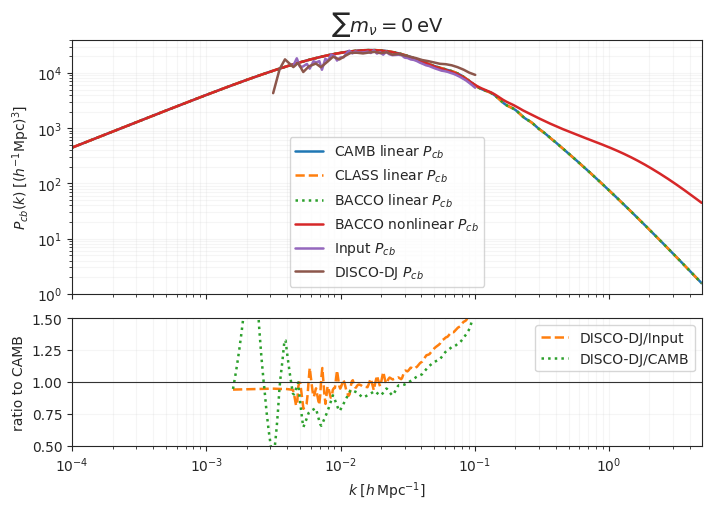

In [109]:
discodj_data = list(np.load("discodj_results.npy", allow_pickle=True))
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7, 5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

entries = [d for d in discodj_data if np.isclose(d["a"], 1)]
entry0 = next(d for d in entries if np.isclose(d["mass"], 0.0))
entrym = next(d for d in entries if not np.isclose(d["mass"], 0.0))
Pk = np.exp(interp1d(np.log(entry0["k"]), np.log(entry0["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
Pk_nu =  np.exp(interp1d(np.log(entrym["k"]), np.log(entrym["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))

Pk_in = np.exp(interp1d(np.log(k_pre), np.log(Pk_pre), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))


ax.loglog(k_h, P_camb_cb_grid, color="C0", lw=1.8, label=r"CAMB linear $P_{cb}$")
ax.loglog(k_h, Pkbc_CLASS, color="C1", lw=1.8, ls="--", label=r"CLASS linear $P_{cb}$")
ax.loglog(k_h, pk_ref, color="C2", lw=1.8, ls=":", label=r"BACCO linear $P_{cb}$")
ax.loglog(k_h, pk_nl_ref, color="C3", lw=1.8, label=r"BACCO nonlinear $P_{cb}$")
ax.loglog(k_pre, Pk_pre, color="C4", lw=1.8, label=r"Input $P_{cb}$")
ax.loglog(entry0["k"], entry0["Pcb"], color="C5", lw=1.8, label=r"DISCO-DJ $P_{cb}$")
#ax.loglog(k_h, Pcb_EB, color="C4", lw=2.1, label=r"DISCOEB linear $P_{cb}$")

ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend()
ax.grid(True, which="both", alpha=0.18)
ax.set_title(rf"$\sum m_\nu = 0\,\mathrm{{eV}}$",fontsize=14)

axr.semilogx(k_h, Pk / Pk_in, color="C1", lw=1.8, ls="--", label="DISCO-DJ/Input")
axr.semilogx(k_h, Pk / P_camb_cb_grid, color="C2", lw=1.8, ls=":", label="DISCO-DJ/CAMB")

axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio to CAMB")
axr.set_xlim(k_h.min(), k_h.max())

axr.set_ylim(0.5,1.5)
axr.legend()
axr.grid(True, which="both", alpha=0.18)

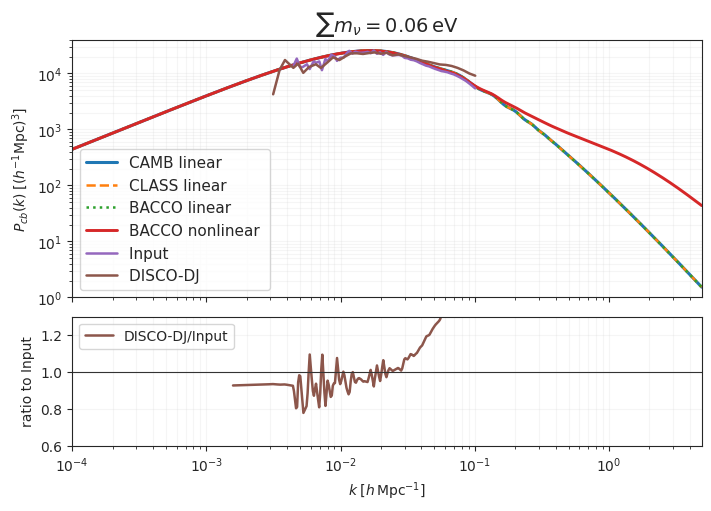

In [110]:
discodj_data = list(np.load("discodj_results.npy", allow_pickle=True))
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7, 5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

entries = [d for d in discodj_data if np.isclose(d["a"], 1)]
entry0 = next(d for d in entries if np.isclose(d["mass"], 0.0))
entrym = next(d for d in entries if not np.isclose(d["mass"], 0.0))
Pk = np.exp(interp1d(np.log(entry0["k"]), np.log(entry0["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
Pk_nu =  np.exp(interp1d(np.log(entrym["k"]), np.log(entrym["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))

Pk_in = np.exp(interp1d(np.log(k_pre_nu), np.log(Pk_pre_nu), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))


ax.loglog(k_h, P_camb_cb_grid_nu, color="C0", lw=2.2, label=r"CAMB linear")
ax.loglog(k_h, Pkbc_CLASS_nu, color="C1", lw=1.8, ls="--", label=r"CLASS linear ")
ax.loglog(k_h, pk_lin, color="C2", lw=1.8, ls=":", label=r"BACCO linear ")
ax.loglog(k_h, pk_nl, color="C3", lw=2.1, label=r"BACCO nonlinear ")
ax.loglog(k_pre_nu, Pk_pre_nu, color="C4", lw=1.8, label=r"Input ")
ax.loglog(entrym["k"], entrym["Pcb"], color="C5", lw=1.8, label=r"DISCO-DJ ")
#ax.loglog(k_h, Pcb_EB, color="C4", lw=2.1, label=r"DISCOEB linear $P_{cb}$")

ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend(prop={'size': 11})
ax.grid(True, which="both", alpha=0.18)
ax.set_title(rf"$\sum m_\nu = {sum_mnu}\,\mathrm{{eV}}$",fontsize=14)

axr.semilogx(k_h, Pk_nu / Pk_in, color="C5", lw=1.8, label="DISCO-DJ/Input")
#axr.semilogx(k_h, Pk_nu / P_camb_cb_grid, color="C2", lw=1.8, ls=":", label="DISCO-DJ/CAMB")

axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio to Input")
axr.set_xlim(k_h.min(), k_h.max())

axr.set_ylim(0.6,1.3)
axr.legend(loc=2,prop={'size': 10})
axr.grid(True, which="both", alpha=0.18)
#plt.savefig('spectra_lin.pgf')

/tmp/ipykernel_2051408/604263322.py:82: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axr.set_ylim(1e-4,0)


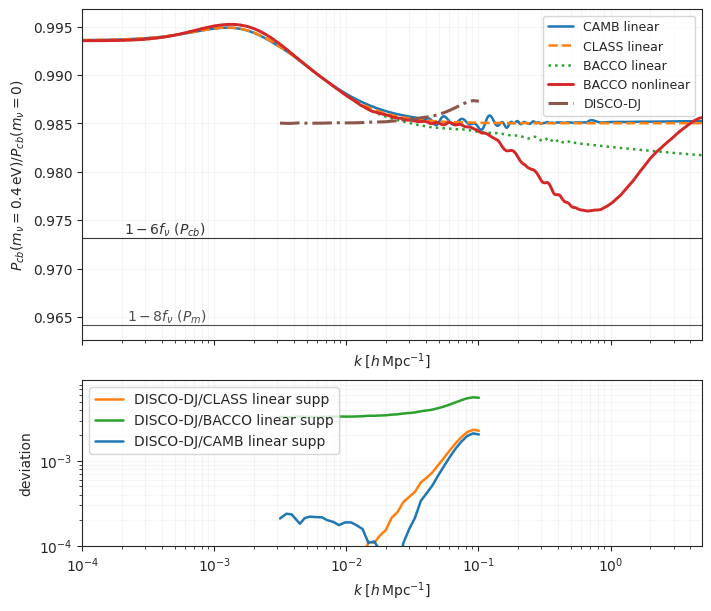

In [111]:
discodj_data = np.load("discodj_results.npy", allow_pickle=True)
discodj_data = [d for d in discodj_data if np.isclose(d["a"], a_end)]
entries = [d for d in discodj_data if np.isclose(d["a"], a_end)]
entry0 = next(d for d in entries if np.isclose(d["mass"], 0.0))
entrym = next(d for d in entries if not np.isclose(d["mass"], 0.0))
k = entry0["k"]
Pk = entry0["Pcb"]
Pk_nu = entrym["Pcb"]

fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7, 6),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

# Ratios massive / massless
ratio_camb     = P_camb_cb_grid_nu / P_camb_cb_grid
ratio_class    = Pkbc_CLASS_nu     / Pkbc_CLASS
ratio_bacco    = pk_lin            / pk_ref
ratio_bacco_nl = pk_nl             / pk_nl_ref
ratio_disco_dj = Pk_nu             / Pk
# ratio_disco = Pcb_EB_nu / Pcb_EB

ax.semilogx(k_h,ratio_camb,color="C0",lw=1.8,label="CAMB linear",)
ax.semilogx(k_h,ratio_class,color="C1",lw=1.8,ls="--",label="CLASS linear",)
ax.semilogx(k_h,ratio_bacco,color="C2",lw=1.8,ls=":",label="BACCO linear",)
ax.semilogx(k_h,ratio_bacco_nl,color="C3",lw=2.1,label="BACCO nonlinear",)
ax.semilogx(k,ratio_disco_dj,color="C5", linestyle='-.',lw=2.2,label="DISCO-DJ",)
# ax.semilogx(k_h, ratio_disco, color="C4", lw=2.1, label="DISCOEB")

class_supp = ratio_class[-1]
camb_supp = ratio_camb[-1]
bacco_supp = ratio_bacco[-1]
ax.axhline(supp_Pcb, color="0.2", lw=0.8)
ax.axhline(supp_P,   color="0.3", lw=0.8)

ax.annotate(
    r"$1-6f_\nu$ ($P_{cb}$)",
    xy=(0.2, supp_Pcb),
    xycoords=("axes fraction", "data"),
    ha="right",
    va="bottom",
    color="0.2",
)

ax.annotate(
    r"$1-8f_\nu$ ($P_m$)",
    xy=(0.2, supp_P),
    xycoords=("axes fraction", "data"),
    ha="right",
    va="bottom",
    color="0.3",
)

ax.set_xscale("log")
ax.set_xlim(k_h.min(), k_h.max())

ax.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
ax.set_ylabel(
    r"$P_{cb}(m_\nu=0.4\,{\rm eV}) / P_{cb}(m_\nu=0)$"
)

#ax.set_title(r"Suppression due to $\sum m_\nu $")

ax.legend(prop={'size': 9},loc=1)
ax.grid(True, which="both", alpha=0.18)

axr.semilogx(k, abs(ratio_disco_dj-class_supp), color="C1", lw=1.8, label="DISCO-DJ/CLASS linear supp")
axr.semilogx(k, abs(ratio_disco_dj-bacco_supp), color="C2", lw=1.8, label="DISCO-DJ/BACCO linear supp")
axr.semilogx(k, abs(ratio_disco_dj-camb_supp), color="C0", lw=1.8, label="DISCO-DJ/CAMB linear supp")

axr.axhline(0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("deviation")
axr.set_xlim(k_h.min(), k_h.max())

axr.set_yscale("log")
axr.set_ylim(1e-4,0)
axr.legend(prop={'size': 10},loc=2)
axr.grid(True, which="both", alpha=0.18)

plt.show()
#plt.savefig('supp_lin.pgf')

## Non-linear Suppresion (Scale dep)

In [122]:
# Set the parameters
name = "3D_analysis"
dim = 3
precision = "double"
if precision == "double":
    config.update("jax_enable_x64", True)

# Define the boxsize and resolution
boxsize = 1000  # in Mpc/h
res = 256  # the particles live on a Lagrangrian grid of resolution (res)^dim

results_disco = []

# The cosmology can be provided as a dictionary or a string for a pre-defined cosmology (e.g. "CamelsCV" for the Camels Cosmic Variance suite).
# cosmo = "CamelsCV"
cosmo = dict(Omega_c=omega_cdm,  # cold dark matter content
             Omega_b=omega_b,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
             h=h,  # dimensionless Hubble constant
             n_s=n_s,  # scalar spectral index
             sigma8=0.8159,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
             mnu = 0) #Neutrino mass (eV)

dj = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)
print(dj)
dj = dj.with_timetables()
dj = dj.with_linear_ps(fix_sigma8=True, transfer_function="from_file", filename="Pk_cb_massless_z0_CLASS.txt")
white_noise_field = dj.get_ngenic_noise(seed=13)  # a white noise field, defined in real space
dj = dj.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
k_pre_nl, Pk_pre_nl, _ = dj.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)

n_order = 2
stepper = "bullfrog"
method = "pm"
res_pm = dj.res
time_var = "D"
antialias = 0
grad_kernel_order = 4
laplace_kernel_order = 0
worder = 2
n_resample = 3
deconvolve = True
nlpt_order_ics = n_order
chunk_size = None  # if you are running out of GPU memory, doing the mass assignment in smaller chunks might help (e.g. chunk_size = dj.res ** dj.dim // 16)

for a_end in a_targets:

    numsteps = 10 # number of steps to be performed
    a_ini = 0.02  # initial scale factor of the simulation (where it is initialized with LPT)
    a_list = np.linspace(a_ini, a_end, numsteps, endpoint=True)

    
    dj = dj.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
    X_sim, P_sim, a_sim = dj.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                    time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                    grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                    nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                    deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                    convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
    delta_sim = dj.get_delta_from_pos(X_sim, res= dj.res, n_resample=n_resample)
    k, Pk, _ = dj.evaluate_power_spectrum(delta_sim, bins=dj.res//3, deconvolve=deconvolve, worder=worder)

    results_disco.append({
            "k": k,
            "Pcb": Pk,
            "mass": 0,
            "method": "DISCODJ",
            "a": a_end                                                               
        }) 

###########################################################################################################################################################################



cosmo_nu = dict(Omega_c=omega_cdm,  # cold dark matter content
            Omega_b=omega_b,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
            h=h,  # dimensionless Hubble constant
            n_s=n_s,  # scalar spectral index
            sigma8=0.8159,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
            mnu = sum_mnu/3) #Neutrino mass (eV)
dj_nu = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo_nu)
print(dj_nu)
dj_nu = dj_nu.with_timetables()
dj_nu = dj_nu.with_linear_ps(fix_sigma8=True, transfer_function="from_file", filename=f"Pk_cb_sumMnu_{sum_mnu:.2f}eV_z0_CLASS.txt")
dj_nu = dj_nu.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
k_pre_nu_nl, Pk_pre_nu_nl, _ = dj_nu.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)
for a_end in a_targets:
    numsteps = 10  # number of steps to be performed
    a_ini = 0.02  # initial scale factor of the simulation (where it is initialized with LPT)
    a_list = np.linspace(a_ini, a_end, numsteps, endpoint=True)
    dj_nu = dj_nu.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
    X_sim_nu, P_sim_nu, a_sim_nu = dj_nu.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                    time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                    grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                    nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                    deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                    convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
    delta_sim_nu = dj_nu.get_delta_from_pos(X_sim_nu, res= dj.res, n_resample=n_resample)
    k_nu, Pk_nu, _ = dj_nu.evaluate_power_spectrum(delta_sim_nu, bins=dj.res//3, deconvolve=deconvolve, worder=worder)
    results_disco.append({
        "k": k,
        "Pcb": Pk_nu,
        "mass": sum_mnu,
        "method": "DISCODJ",
        "a": a_end                                                               
    })  

np.save("discodj_nl_results.npy", results_disco)

DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 256³ particles
Boxsize: 1000.0 Mpc/h
Precision: double
Device: gpu
Cosmology:
  Omega_c: 0.2700 
  Omega_b: 0.0490 
  Omega_de: 0.6809 
  h: 0.6700 
  n_s: 0.9619 
  sigma8: 0.8159 
  Omega_k: 0.0000 
  w0: -1.0000 
  wa: 0.0000 
  mnu: 0.0000 
sigma8 according to file: 0.8506, sigma8 according to cosmology: 0.8159. The value of sigma8 will be normalized to the cosmology.
DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 256³ particles
Boxsize: 1000.0 Mpc/h
Precision: double
Device: gpu
Cosmology:
  Omega_c: 0.2700 
  Omega_b: 0.0490 
  Omega_de: 0.6795 
  h: 0.6700 
  n_s: 0.9619 
  sigma8: 0.8159 
  Omega_k: 0.0000 
  w0: -1.0000 
  wa: 0.0000 
  mnu: 0.0200 
sigma8 according to file: 0.8442, sigma8 according to cosmology: 0.8159. The value of sigma8 will be normalized to the cosmology.


In [123]:
#discodj_data = list(np.load("discodj_nl_results.npy", allow_pickle=True))
#
#fig, axes = plt.subplots(2, 2, figsize=(10, 8))
#axes = axes.ravel()
#
#
#for i, a_end in enumerate(a_targets):
#
#    entries = [d for d in discodj_data if np.isclose(d["a"], a_end)]
#    entry0 = next(d for d in entries if np.isclose(d["mass"], 0.0))
#    entrym = next(d for d in entries if not np.isclose(d["mass"], 0.0))
#    k = entry0["k"]
#    Pk = entry0["Pcb"]
#    Pk_nu = entrym["Pcb"]
#
#    ax = axes[i]
#    # -------- INPUT --------
#    ax.plot(k_pre_nl, Pk_pre_nl, color="C4", linestyle='-', label="Input massless")
#    ax.plot(k_pre_nu_nl, Pk_pre_nu_nl,color="C4", linestyle='--', label="Input massive")
#
#    # -------- REF --------
#    ax.plot(k_h, Pkbc_CLASS, color="C1", lw=1.8, linestyle='-', label="CLASS massless")
#    ax.plot(k_h, Pkbc_CLASS_nu, color="C1", lw=1.8, linestyle='--', label="CLASS massive")
#
#    ax.plot(k_h, pk_ref, color="C2", lw=1.8, linestyle='-', label="BACCO massless ")
#    ax.plot(k_h, pk_lin, color="C2", lw=1.8, linestyle='--', label="BACCO massive ")
#    ax.plot(k_h, pk_nl_ref, color="C3", lw=1.8, linestyle='-', label="BACCO massless NL")
#    ax.plot(k_h, pk_nl, color="C3", lw=1.8, linestyle='--', label="BACCO massive NL")
#
#    ax.loglog(k_h, P_camb_cb_grid, color="C0", lw=1.8,linestyle='-', label="CAMB massless")
#    ax.loglog(k_h, P_camb_cb_grid_nu, color="C0", lw=1.8,linestyle='--', label="CAMB massive")
#
#
#    # -------- OUTPUT (DISCO) --------
#    ax.plot(k, Pk, color="C5", linestyle='-', label="DISCO massless")
#    ax.plot(k, Pk_nu, color="C5", linestyle='--', label="DISCO massive")
#    ax.set_xlim(1e-3, 0.5)
#    ax.set_ylim(10, 5e5)
#    ax.set_xscale("log")
#    ax.set_yscale("log")
#    ax.set_title(f"a = {a_end}")
#    ax.set_xlabel("k [h/Mpc]")
#    ax.set_ylabel("P(k)")
#    ax.grid(True, which="both", alpha=0.3)
#
## legend unique
#handles, labels = axes[0].get_legend_handles_labels()
#fig.legend(handles, labels, loc="lower center", ncol=6)
#
#plt.tight_layout(rect=[0, 0.05, 1, 1])
#plt.show()

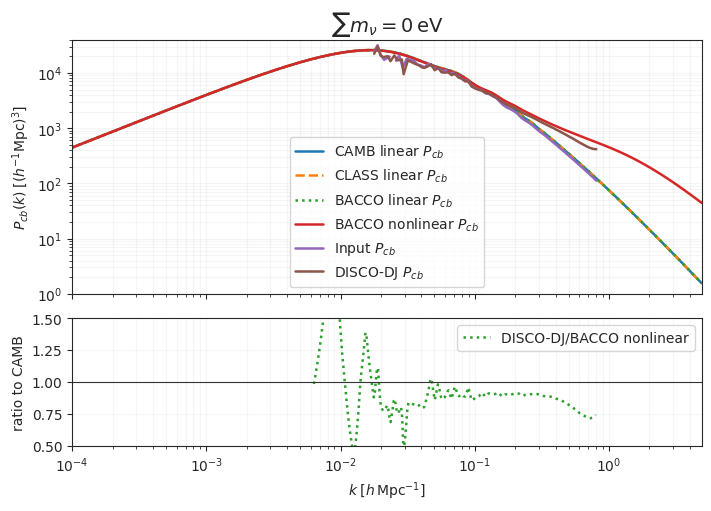

In [124]:
discodj_data = list(np.load("discodj_nl_results.npy", allow_pickle=True))
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7, 5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

entries = [d for d in discodj_data if np.isclose(d["a"], 1)]
entry0 = next(d for d in entries if np.isclose(d["mass"], 0.0))
entrym = next(d for d in entries if not np.isclose(d["mass"], 0.0))
Pk = np.exp(interp1d(np.log(entry0["k"]), np.log(entry0["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
Pk_nu =  np.exp(interp1d(np.log(entrym["k"]), np.log(entrym["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))

Pk_in = np.exp(interp1d(np.log(k_pre_nl), np.log(Pk_pre_nl), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))


ax.loglog(k_h, P_camb_cb_grid, color="C0", lw=1.8, label=r"CAMB linear $P_{cb}$")
ax.loglog(k_h, Pkbc_CLASS, color="C1", lw=1.8, ls="--", label=r"CLASS linear $P_{cb}$")
ax.loglog(k_h, pk_ref, color="C2", lw=1.8, ls=":", label=r"BACCO linear $P_{cb}$")
ax.loglog(k_h, pk_nl_ref, color="C3", lw=1.8, label=r"BACCO nonlinear $P_{cb}$")
ax.loglog(k_pre_nl, Pk_pre_nl, color="C4", lw=1.8, label=r"Input $P_{cb}$")
ax.loglog(entry0["k"], entry0["Pcb"], color="C5", lw=1.8, label=r"DISCO-DJ $P_{cb}$")
#ax.loglog(k_h, Pcb_EB, color="C4", lw=2.1, label=r"DISCOEB linear $P_{cb}$")

ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend()
ax.grid(True, which="both", alpha=0.18)
ax.set_title(rf"$\sum m_\nu = 0\,\mathrm{{eV}}$",fontsize=14)

#axr.semilogx(k_h, Pk / Pk_in, color="C1", lw=1.8, ls="--", label="DISCO-DJ/Input")
axr.semilogx(k_h, Pk / pk_nl_ref, color="C2", lw=1.8, ls=":", label="DISCO-DJ/BACCO nonlinear")

axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio to CAMB")
axr.set_xlim(k_h.min(), k_h.max())

axr.set_ylim(0.5,1.5)
axr.legend()
axr.grid(True, which="both", alpha=0.18)

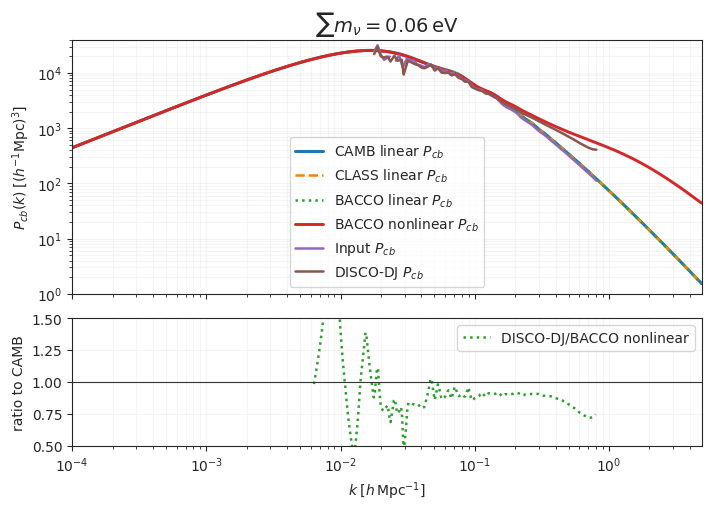

In [125]:
discodj_data = list(np.load("discodj_nl_results.npy", allow_pickle=True))
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7, 5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

entries = [d for d in discodj_data if np.isclose(d["a"], 1)]
entry0 = next(d for d in entries if np.isclose(d["mass"], 0.0))
entrym = next(d for d in entries if not np.isclose(d["mass"], 0.0))
Pk = np.exp(interp1d(np.log(entry0["k"]), np.log(entry0["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
Pk_nu =  np.exp(interp1d(np.log(entrym["k"]), np.log(entrym["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))

Pk_in = np.exp(interp1d(np.log(k_pre_nu_nl), np.log(Pk_pre_nu_nl), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))


ax.loglog(k_h, P_camb_cb_grid_nu, color="C0", lw=2.2, label=r"CAMB linear $P_{cb}$")
ax.loglog(k_h, Pkbc_CLASS_nu, color="C1", lw=1.8, ls="--", label=r"CLASS linear $P_{cb}$")
ax.loglog(k_h, pk_lin, color="C2", lw=1.8, ls=":", label=r"BACCO linear $P_{cb}$")
ax.loglog(k_h, pk_nl, color="C3", lw=2.1, label=r"BACCO nonlinear $P_{cb}$")
ax.loglog(k_pre_nu_nl, Pk_pre_nu_nl, color="C4", lw=1.8, label=r"Input $P_{cb}$")
ax.loglog(entrym["k"], entrym["Pcb"], color="C5", lw=1.8, label=r"DISCO-DJ $P_{cb}$")
#ax.loglog(k_h, Pcb_EB, color="C4", lw=2.1, label=r"DISCOEB linear $P_{cb}$")

ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend()
ax.grid(True, which="both", alpha=0.18)
ax.set_title(rf"$\sum m_\nu = {sum_mnu}\,\mathrm{{eV}}$",fontsize=14)

#axr.semilogx(k_h, Pk_nu / Pk_in, color="C1", lw=1.8, ls="--", label="DISCO-DJ/Input")
axr.semilogx(k_h, Pk_nu / pk_nl, color="C2", lw=1.8, ls=":", label="DISCO-DJ/BACCO nonlinear")

axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio to CAMB")
axr.set_xlim(k_h.min(), k_h.max())

axr.set_ylim(0.5,1.5)
axr.legend()
axr.grid(True, which="both", alpha=0.18)

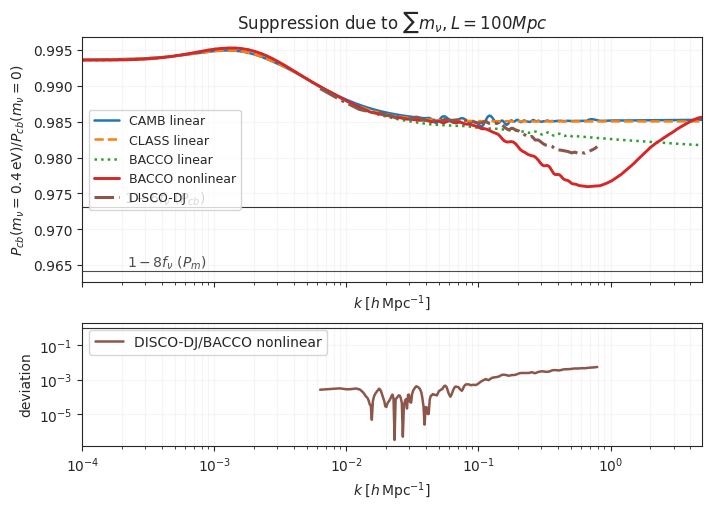

In [126]:
entries = [d for d in discodj_data if np.isclose(d["a"], 1)]
entry0 = next(d for d in entries if np.isclose(d["mass"], 0.0))
entrym = next(d for d in entries if not np.isclose(d["mass"], 0.0))
Pk = np.exp(interp1d(np.log(entry0["k"]), np.log(entry0["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
Pk_nu =  np.exp(interp1d(np.log(entrym["k"]), np.log(entrym["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))

Pk_in = np.exp(interp1d(np.log(k_pre_nu_nl), np.log(Pk_pre_nu_nl), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))

fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7, 5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)
# Ratios massive / massless
ratio_camb     = P_camb_cb_grid_nu / P_camb_cb_grid
ratio_class    = Pkbc_CLASS_nu    / Pkbc_CLASS
ratio_bacco    = pk_lin           / pk_ref
ratio_bacco_nl = pk_nl            / pk_nl_ref
ratio_dj       = Pk_nu/Pk
# ratio_disco = Pcb_EB_nu / Pcb_EB

ax.semilogx(k_h,ratio_camb,color="C0",lw=1.8,label="CAMB linear",)
ax.semilogx(k_h,ratio_class,color="C1",lw=1.8,ls="--",label="CLASS linear",)
ax.semilogx(k_h,ratio_bacco,color="C2",lw=1.8,ls=":",label="BACCO linear",)
ax.semilogx(k_h,ratio_bacco_nl,color="C3",lw=2.1,label="BACCO nonlinear",)
ax.semilogx(k_h,ratio_dj,color="C5", linestyle='-.',lw=2.2,label="DISCO-DJ",)
# ax.semilogx(k_h, ratio_disco, color="C4", lw=2.1, label="DISCOEB")

ax.axhline(supp_Pcb, color="0.2", lw=0.8)
ax.axhline(supp_P,   color="0.3", lw=0.8)

ax.annotate(
    r"$1-6f_\nu$ ($P_{cb}$)",
    xy=(0.2, supp_Pcb),
    xycoords=("axes fraction", "data"),
    ha="right",
    va="bottom",
    color="0.2",
)

ax.annotate(
    r"$1-8f_\nu$ ($P_m$)",
    xy=(0.2, supp_P),
    xycoords=("axes fraction", "data"),
    ha="right",
    va="bottom",
    color="0.3",
)

ax.set_xscale("log")
ax.set_xlim(k_h.min(), k_h.max())

ax.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
ax.set_ylabel(
    r"$P_{cb}(m_\nu=0.4\,{\rm eV}) / P_{cb}(m_\nu=0)$"
)

ax.set_title(rf"Suppression due to $\sum m_\nu , L=100 Mpc$")

ax.legend(prop={'size': 9})
ax.grid(True, which="both", alpha=0.18)

axr.semilogx(k_h, abs(ratio_dj /  ratio_bacco_nl-1), color="C5", lw=1.8, label="DISCO-DJ/BACCO nonlinear")


axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("deviation")
axr.set_xlim(k_h.min(), k_h.max())

#axr.set_ylim(0.97,1.03)
axr.set_yscale("log")
axr.legend(prop={'size': 10},loc=2)
axr.grid(True, which="both", alpha=0.18)
#plt.savefig('supp_nl.pgf')